<a href="https://colab.research.google.com/github/Anggardy/Customer_retention_analysis/blob/main/EGroceries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Setup data

In [ ]:
df= pd.read_csv('/content/drive/MyDrive/Portfolio/Data Analyst/Retail Shop/Data/master_data_retail.csv', delimiter=',')

df

,sales_id,order_id,customer_id,customer_name,age,gender,city,state,product_id,product_name,...,size,colour,stok,harga_produk,harga_jual,quantity,total_price,order_date,delivery_date,delivery_time
0,0,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,218,Chambray,...,L,orange,44,105.0,106.0,2,212.0,2021-08-30,2021-09-24,25
1,1,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,481,Puffer,...,S,indigo,62,110.0,118.0,1,118.0,2021-08-30,2021-09-24,25
2,2,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,2,Oxford Cloth,...,M,red,54,114.0,96.0,3,288.0,2021-08-30,2021-09-24,25
3,3,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,1002,Wool,...,M,blue,52,111.0,106.0,2,212.0,2021-08-30,2021-09-24,25
4,4,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,691,Parka,...,S,indigo,53,119.0,113.0,3,339.0,2021-08-30,2021-09-24,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5002,4996,998,407,Murdock Bulfit,41,Male,Hartmannshire,Queensland,251,Polo,...,S,orange,78,117.0,95.0,3,285.0,2021-05-05,2021-05-21,16
5003,4997,999,428,Jammal Varcoe,66,Polygender,North Liamfort,Australian Capital Territory,872,Chinos,...,M,violet,54,100.0,113.0,1,113.0,2021-06-15,2021-07-12,27
5004,4998,999,428,Jammal Varcoe,66,Polygender,North Liamfort,Australian Capital Territory,998,Wool,...,L,green,42,111.0,106.0,2,212.0,2021-06-15,2021-07-12,27
5005,4999,999,428,Jammal Varcoe,66,Polygender,North Liamfort,Australian Capital Territory,1105,Cropped,...,XS,blue,47,99.0,115.0,1,115.0,2021-06-15,2021-07-12,27


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5007 entries, 0 to 5006
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sales_id       5007 non-null   int64  
 1   order_id       5007 non-null   int64  
 2   customer_id    5007 non-null   int64  
 3   customer_name  5007 non-null   object 
 4   age            5007 non-null   int64  
 5   gender         5007 non-null   object 
 6   city           5007 non-null   object 
 7   state          5007 non-null   object 
 8   product_id     5007 non-null   int64  
 9   product_name   5000 non-null   object 
 10  product_type   5000 non-null   object 
 11  size           5000 non-null   object 
 12  colour         5000 non-null   object 
 13  stok           5007 non-null   int64  
 14  harga_produk   5007 non-null   float64
 15  harga_jual     5007 non-null   float64
 16  quantity       5007 non-null   int64  
 17  total_price    5007 non-null   float64
 18  order_da

# Cleaning Data

In [ ]:
clean_df = df.copy()

## Penanganan Data Null

In [ ]:
data_null = clean_df.isna().sum()
print(data_null)

sales_id         0
order_id         0
customer_id      0
customer_name    0
age              0
gender           0
city             0
state            0
product_id       0
product_name     7
product_type     7
size             7
colour           7
stok             0
harga_produk     0
harga_jual       0
quantity         0
total_price      0
order_date       0
delivery_date    0
delivery_time    0
dtype: int64


In [ ]:
clean_df = clean_df.dropna()

In [ ]:
# Let's verify that the nulls have been removed
print(clean_df.isna().sum())

sales_id         0
order_id         0
customer_id      0
customer_name    0
age              0
gender           0
city             0
state            0
product_id       0
product_name     0
product_type     0
size             0
colour           0
stok             0
harga_produk     0
harga_jual       0
quantity         0
total_price      0
order_date       0
delivery_date    0
delivery_time    0
dtype: int64


## Penanganan data duplikat

In [ ]:
data_dup = clean_df.duplicated().sum()
print(f"Number of duplicate rows: {data_dup}")

Number of duplicate rows: 0


## Formatting data

In [ ]:
clean_df.head()

,sales_id,order_id,customer_id,customer_name,age,gender,city,state,product_id,product_name,...,size,colour,stok,harga_produk,harga_jual,quantity,total_price,order_date,delivery_date,delivery_time
0,0,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,218,Chambray,...,L,orange,44,105.0,106.0,2,212.0,2021-08-30,2021-09-24,25
1,1,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,481,Puffer,...,S,indigo,62,110.0,118.0,1,118.0,2021-08-30,2021-09-24,25
2,2,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,2,Oxford Cloth,...,M,red,54,114.0,96.0,3,288.0,2021-08-30,2021-09-24,25
3,3,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,1002,Wool,...,M,blue,52,111.0,106.0,2,212.0,2021-08-30,2021-09-24,25
4,4,1,64,Annabella Devote,75,Genderfluid,Sanfordborough,South Australia,691,Parka,...,S,indigo,53,119.0,113.0,3,339.0,2021-08-30,2021-09-24,25


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5005
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sales_id       5000 non-null   int64  
 1   order_id       5000 non-null   int64  
 2   customer_id    5000 non-null   int64  
 3   customer_name  5000 non-null   object 
 4   age            5000 non-null   int64  
 5   gender         5000 non-null   object 
 6   city           5000 non-null   object 
 7   state          5000 non-null   object 
 8   product_id     5000 non-null   int64  
 9   product_name   5000 non-null   object 
 10  product_type   5000 non-null   object 
 11  size           5000 non-null   object 
 12  colour         5000 non-null   object 
 13  stok           5000 non-null   int64  
 14  harga_produk   5000 non-null   float64
 15  harga_jual     5000 non-null   float64
 16  quantity       5000 non-null   int64  
 17  total_price    5000 non-null   float64
 18  order_date   

Ubah waktu

In [ ]:
clean_df['order_date'] = pd.to_datetime(clean_df['order_date'])
clean_df['delivery_date'] = pd.to_datetime(clean_df['delivery_date'])

Ubah format id

In [ ]:
clean_df['order_id'] = clean_df['order_id'].astype(str)
clean_df['sales_id'] = clean_df['sales_id'].astype(str)
clean_df['customer_id'] = clean_df['customer_id'].astype(str)
clean_df['product_id'] = clean_df['product_id'].astype(str)

Membuat kolom year_month

In [ ]:
clean_df['year_month'] = clean_df['order_date'].dt.to_period('M')

## Cek Outlier

In [ ]:
# Display descriptive statistics for numerical columns
print(clean_df.describe())

               age         stok  harga_produk   harga_jual    quantity  \
count  5000.000000  5000.000000   5000.000000  5000.000000  5000.00000   
mean     48.760400    60.083400    105.665400   103.501600     1.99240   
min      20.000000    40.000000     90.000000    90.000000     1.00000   
25%      34.000000    50.000000     95.000000    95.000000     1.00000   
50%      48.000000    60.000000    108.000000   102.000000     2.00000   
75%      63.000000    70.000000    114.000000   112.000000     3.00000   
max      80.000000    80.000000    119.000000   119.000000     3.00000   
std      17.577519    11.682523      9.735564     9.195004     0.80751   

       total_price                  order_date               delivery_date  \
count  5000.000000                        5000                        5000   
mean    206.360000  2021-05-25 15:10:39.360000  2021-06-08 14:56:32.640000   
min      90.000000         2021-01-01 00:00:00         2021-01-03 00:00:00   
25%     112.000000   

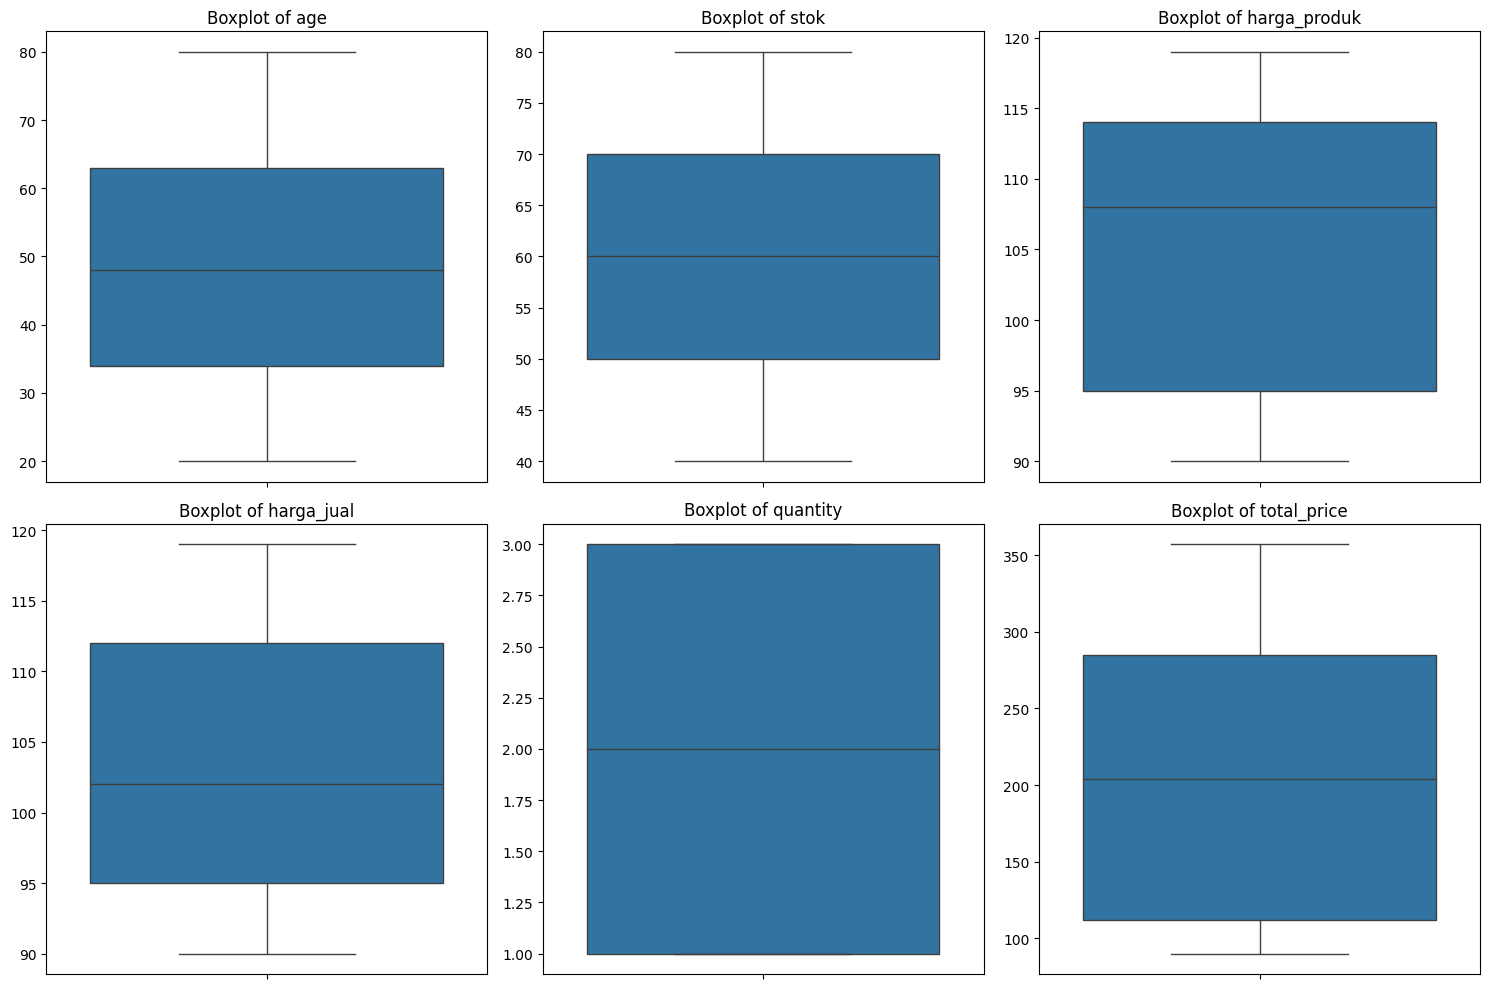

In [ ]:
numerical_cols = ['age', 'stok', 'harga_produk', 'harga_jual', 'quantity', 'total_price']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=clean_df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()

# Analisis

# Membuat Customer Retention Cohort

Melakukan agregasi data

In [ ]:
df_customer_monthly = clean_df.groupby(
    ['customer_id', 'year_month'],
    as_index=False
).agg(
    order_cnt=(
        'order_id',
        'nunique'
    )
)

df_customer_monthly

,customer_id,year_month,order_cnt
0,1,2021-02,1
1,1,2021-03,1
2,1,2021-04,1
3,10,2021-03,1
4,100,2021-01,2
...,...,...,...
944,996,2021-09,1
945,998,2021-01,1
946,998,2021-02,1
947,998,2021-03,1


Membuat kolom cohort dari pelanggan

In [ ]:
df_customer_monthly['cohort'] = df_customer_monthly.groupby(
    'customer_id'
)['year_month'].transform('min')

df_customer_monthly

,customer_id,year_month,order_cnt,cohort
0,1,2021-02,1,2021-02
1,1,2021-03,1,2021-02
2,1,2021-04,1,2021-02
3,10,2021-03,1,2021-03
4,100,2021-01,2,2021-01
...,...,...,...,...
944,996,2021-09,1,2021-03
945,998,2021-01,1,2021-01
946,998,2021-02,1,2021-01
947,998,2021-03,1,2021-01


Menghitung jarak belanja ulang

In [ ]:
from operator import attrgetter

df_customer_monthly['period_num']=(
    df_customer_monthly['year_month'] - df_customer_monthly['cohort']
).apply(
    attrgetter('n')
) + 1

df_customer_monthly

,customer_id,year_month,order_cnt,cohort,period_num
0,1,2021-02,1,2021-02,1
1,1,2021-03,1,2021-02,2
2,1,2021-04,1,2021-02,3
3,10,2021-03,1,2021-03,1
4,100,2021-01,2,2021-01,1
...,...,...,...,...,...
944,996,2021-09,1,2021-03,7
945,998,2021-01,1,2021-01,1
946,998,2021-02,1,2021-01,2
947,998,2021-03,1,2021-01,3


Pivot table untuk membuat analisis Customer Retention

In [ ]:
df_cohort_pivot = pd.pivot_table(
    df_customer_monthly,
    index='cohort',
    columns='period_num',
    values='customer_id',
    aggfunc=pd.Series.nunique
)

df_cohort_pivot

period_num,1,2,3,4,5,6,7,8,9,10
cohort,,,,,,,,,,
2021-01,104.0,13.0,11.0,12.0,10.0,10.0,15.0,10.0,6.0,10.0
2021-02,77.0,13.0,9.0,11.0,5.0,10.0,6.0,6.0,8.0,NaN
2021-03,90.0,5.0,5.0,11.0,12.0,12.0,11.0,11.0,NaN,NaN
2021-04,68.0,4.0,8.0,8.0,6.0,5.0,6.0,NaN,NaN,NaN
2021-05,48.0,7.0,1.0,1.0,6.0,3.0,NaN,NaN,NaN,NaN
2021-06,57.0,8.0,1.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN
2021-07,46.0,7.0,4.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,58.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,44.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Menghitung retention rate

In [ ]:
cohort_size = df_cohort_pivot.iloc[:, 0]
cohort_size

,1
cohort,
2021-01,104.0
2021-02,77.0
2021-03,90.0
2021-04,68.0
2021-05,48.0
2021-06,57.0
2021-07,46.0
2021-08,58.0
2021-09,44.0


In [ ]:
df_retention_cohort = df_cohort_pivot.divide(
    cohort_size,
    axis=0
)

df_retention_cohort

period_num,1,2,3,4,5,6,7,8,9,10
cohort,,,,,,,,,,
2021-01,1.0,0.125000,0.105769,0.115385,0.096154,0.096154,0.144231,0.096154,0.057692,0.096154
2021-02,1.0,0.168831,0.116883,0.142857,0.064935,0.129870,0.077922,0.077922,0.103896,NaN
2021-03,1.0,0.055556,0.055556,0.122222,0.133333,0.133333,0.122222,0.122222,NaN,NaN
2021-04,1.0,0.058824,0.117647,0.117647,0.088235,0.073529,0.088235,NaN,NaN,NaN
2021-05,1.0,0.145833,0.020833,0.020833,0.125000,0.062500,NaN,NaN,NaN,NaN
2021-06,1.0,0.140351,0.017544,0.105263,0.070175,NaN,NaN,NaN,NaN,NaN
2021-07,1.0,0.152174,0.086957,0.152174,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,1.0,0.068966,0.034483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,1.0,0.068182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualisasi

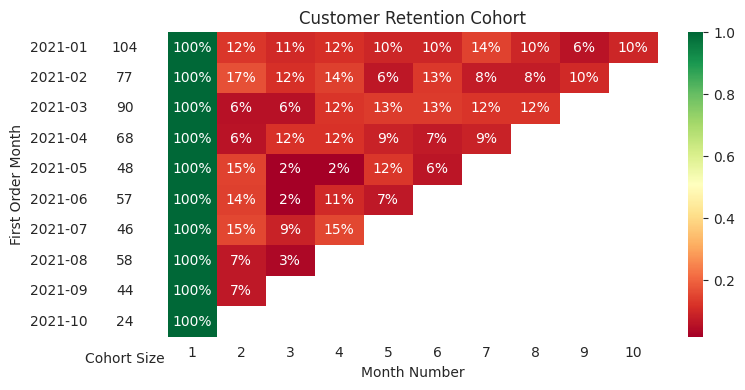

In [34]:
with sns.axes_style('white'):
  fig, ax = plt.subplots(
      1, 2,
      figsize=(8, 4),
      sharey=True,
      gridspec_kw={
          'width_ratios': [1, 11]
      })

  # Customer retention cohort
  sns.heatmap(
      df_retention_cohort,
      annot=True,
      fmt='.0%',
      cmap='RdYlGn',
      ax=ax[1]
  )
  ax[1].set_title('Customer Retention Cohort')
  ax[1].set(xlabel='Month Number', ylabel='')

  # Cohort size
  df_cohort_size = pd.DataFrame(cohort_size)
  white_cmap = mcolors.ListedColormap(['white'])
  sns.heatmap(
      df_cohort_size,
      annot=True,
      cbar=False,
      fmt='g',
      cmap=white_cmap,
      ax=ax[0]
  )

  ax[0].tick_params(bottom=False)
  ax[0].set(
      xlabel='Cohort Size',
      ylabel='First Order Month',
      xticklabels=[]
  )

  fig.tight_layout()